# Interacting Particle Systems

Evolve a cloud of particles under pairwise kernel interactions and compare analytic and automatic gradients. Explore periodic boundaries and chunked computations to connect the continuum interpretation with a practical discrete simulation.


## Run this tour

Run the cells in order with a Python 3 kernel. The first cell locates the companion data and toolbox and installs missing dependencies when needed. All worked examples include their implementation directly in this notebook. Random seeds make comparisons reproducible; you can change them to explore other samples.


In [1]:
# Locate the companion toolbox locally, or fetch it for a standalone/Colab copy.
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

working = Path.cwd()
candidates = [working, working / "python", working.parent / "python"]
python_dir = next((p for p in candidates if (p / "nt_toolbox").is_dir()), None)
if python_dir is None:
    checkout = working / "numerical-tours-support"
    if not checkout.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "master",
                "https://github.com/gpeyre/numerical-tours.git",
                str(checkout),
            ],
            check=True,
        )
    python_dir = checkout / "python"
os.chdir(python_dir)
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))
requirements = python_dir / "requirements.txt"
if any(
    importlib.util.find_spec(name) is None
    for name in [
        "numpy",
        "scipy",
        "matplotlib",
        "skimage",
        "sklearn",
        "pywt",
        "ipywidgets",
        "cvxpy",
        "skfmm",
        "autograd",
        "progressbar",
        "celer",
    ]
):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(requirements)], check=True
    )
if (
    importlib.util.find_spec("torch") is None
    or importlib.util.find_spec("torchvision") is None
):
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-r",
            str(python_dir / "requirements-torch.txt"),
        ],
        check=True,
    )

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "figure.dpi": 100,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "image.cmap": "gray",
    }
)
%matplotlib inline

## Scaling pairwise interactions with chunks

Pairwise interactions require quadratic work. We evaluate the same energy in small blocks to reduce the temporary distance storage, then use automatic differentiation to obtain its gradient. This CPU-compatible implementation keeps the algorithm visible. For much larger point clouds, symbolic reduction libraries such as KeOps provide a further route to scalability.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.manual_seed(0)
torch.set_num_threads(1)
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from time import time
import progressbar

Check if cuda is available (be sure to go to the parameter of the notebook to activate GPU)


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Draw random particles.


In [4]:
n = 256  # number of points
m = 260  # number of points on the second cloud
d = 2  # dimension
X = torch.rand(n, d)
Y = torch.rand(m, d)
print(X.is_cuda)
X = X.to(device)  # put it on gpu
Y = Y.to(device)  # put it on gpu
print(X.is_cuda)

False
False


Handling boundary conditions.


Periodic boundary.


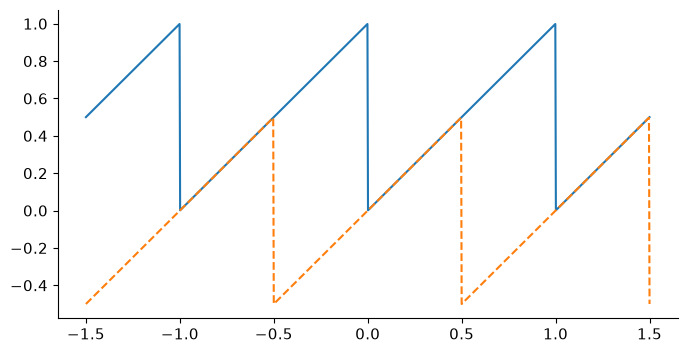

In [5]:
boundary = "no"  # no boundary condition
boundary = "per"  # periodic
if boundary == "no":  # change this for usual BC
    print("No boundary.")

    def bc_pos(X):
        return X

    def bc_diff(D):
        return D
else:
    print("Periodic boundary.")

    def bc_pos(X):
        return torch.remainder(X, 1.0)

    def bc_diff(D):
        return torch.remainder(D - 0.5, 1.0) - 0.5


t = torch.tensor(np.linspace(-1.5, 1.5, 1000))
plt.plot(t, bc_pos(t))
plt.plot(t, bc_diff(t), "--")

Example of how to compute a pairwise distance matrix
$$
  D_{i,j} = \|x_i-y_j\|^2
$$
efficiently using the `None` keyword.


In [6]:
def distmat_square(X, Y):
    return torch.sum(bc_diff(X[:, None, :] - Y[None, :, :]) ** 2, axis=2)

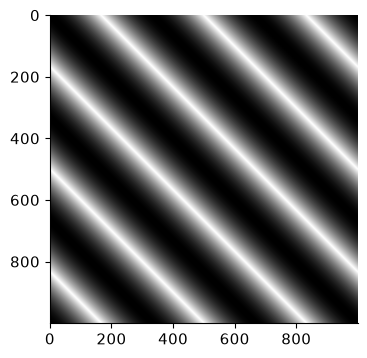

In [7]:
plt.imshow(distmat_square(t[:, None], t[:, None]))

A more memory efficient way (specially in high dimension $d$) way to compute the distance by expanding the squares.


In [8]:
def distmat_square2(X, Y):
    X_sq = (X**2).sum(axis=-1)
    Y_sq = (Y**2).sum(axis=-1)
    cross_term = X.matmul(Y.T)
    return X_sq[:, None] + Y_sq[None, :] - 2 * cross_term

In [9]:
t0 = time()
distmat_square(X, Y)
print(time() - t0)

t0 = time()
distmat_square2(X, Y)
print(time() - t0)

0.0010991096496582031
0.0005099773406982422


# Maximum Mean Discrepencies


When training ML model with point clouds, it is important to be able to compare to pair of clouds. A simple loss function is to use an MMD norm
$$
    \text{MMD}(X,Y) \triangleq
    \frac{1}{n^2} \sum_{i,i'} k(x_i,x_{i'}) 
    +
    \frac{1}{m^2} \sum_{j,j'} k(y_j,y_{j'})
    -2
    \frac{1}{nm} \sum_{i,j} k(x_i,y_{j}).
$$
We use here the energy distance kernel, so that MMD$(X,Y)$ is a dual Sobolev norm between the discrete measure $\frac{1}{n}\sum_i \delta_{x_i}$ and $\frac{1}{m}\sum_i \delta_{y_j}$
$$
  k(x,y) = -\|x-y\|.
$$


In [10]:
def kernel(X, Y):
    return -torch.sqrt(distmat_square(X, Y))


def MMD(X, Y):
    n = X.shape[0]
    m = Y.shape[0]
    a = (
        torch.sum(kernel(X, X)) / n**2
        + torch.sum(kernel(Y, Y)) / m**2
        - 2 * torch.sum(kernel(X, Y)) / (n * m)
    )
    return a.item()

In [11]:
print(MMD(X, X))  # should be 0
print(MMD(X, Y))  # should be >0

0.0
0.0037221312522888184


# Gradient flow with Pytorch


We compute a speed vector field to advances the particlesusing an interaction kernel of the form
$$
  v(X)_i = \frac{1}{n} \sum_j \psi(\|x_i-x_j\|^2) (x_j-x_i)
$$
Note that the evolution
$$
  \dot X = -v(X)
$$
is the Wasserstein gradient flow of the energy
$$
  \sum_{i,j} \phi(\|x_i-y_j\|^2 ).
$$
when defining $\psi(r)=4\phi'(r)$.

If $\phi$ is decreasing (resp. increasing), the flow is repulsive (resp. attractive).


In [12]:
sigma = 0.1


def psi(r):
    return torch.exp(-r / (2 * sigma**2))

In [13]:
def Speed(X):
    return (
        2
        / X.shape[0]
        * 1
        / sigma**2
        * torch.sum(
            psi(distmat_square(X, X))[:, :, None]
            * bc_diff(X[:, None, :] - X[None, :, :]),
            axis=1,
        )
    )

Discretize the evolution $\dot X = -v(X)$.


In [14]:
if boundary == "no":
    tau = 1 / 500  # time step
else:
    tau = 1 / 200
niter = 200
save_per = 10  # periodicity of saving
Zsvg = torch.zeros((n, 2, niter // save_per))  # to store all the intermediate time
Z = X
for it in progressbar.progressbar(range(niter)):
    if np.mod(it, save_per) == 0:
        Zsvg[:, :, it // save_per] = Z.clone().detach().cpu()  # for later display
    Z = bc_pos(Z - tau * Speed(Z))

  0% (0 of 200) |                         | Elapsed Time: 0:00:00 ETA: --:--:--

 16% (31 of 200) |###                      | Elapsed Time: 0:00:00 ETA: 0:00:00

 56% (112 of 200) |#############           | Elapsed Time: 0:00:00 ETA: 0:00:00

 96% (193 of 200) |####################### | Elapsed Time: 0:00:00 ETA: 0:00:00

100% (200 of 200) |########################| Elapsed Time: 0:00:00 ETA: 0:00:00

Display the evolution.


interactive(children=(IntSlider(value=0, description='t', max=19), Output()), _dom_classes=('widget-interact',…

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


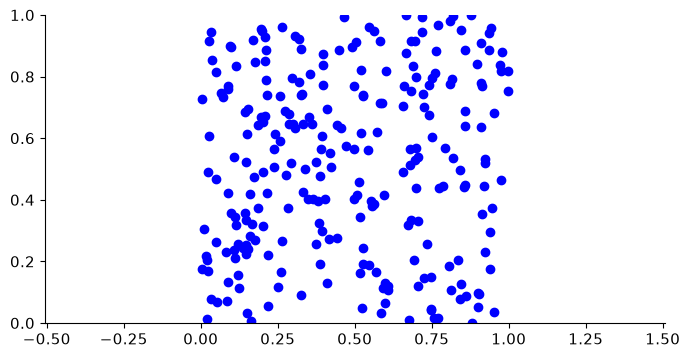

In [15]:
import ipywidgets as widgets


@widgets.interact(t=(0, niter // save_per - 1))
def display_frame(t=0):
    s = t / (niter // save_per - 1)
    plt.scatter(Zsvg[:, 0, t], Zsvg[:, 1, t], color=[s, 0, 1 - s])
    plt.axis("equal")
    plt.axis([0, 1, 0, 1])

# Computing Gradient with Auto-diff

Instead of computing "by hand" the gradient of the interaction energy, one can directly rely on Pytorch auto-diff functionality. This simplifies coding and it reduces bugs in code.


In [16]:
X.requires_grad = True
L = -1 / X.shape[0] * torch.sum(psi(distmat_square(X, X)), axis=(0, 1))
[g] = torch.autograd.grad(L, [X])
# compare with the "by hand" computation
print(
    'Difference "hand" vs. pytorch" : '
    + str(torch.norm(g - Speed(X)).item() / torch.norm(g).item())
)

Difference "hand" vs. pytorch" : 1.6094572346838896e-07


## Scaling pairwise interactions with chunks

Pairwise interactions require quadratic work. We evaluate the same energy in small blocks to reduce the temporary distance storage, then use automatic differentiation to obtain its gradient. This CPU-compatible implementation keeps the algorithm visible. For much larger point clouds, symbolic reduction libraries such as KeOps provide a further route to scalability.


In [17]:
# Chunking limits the size of each pairwise-distance block.
def interaction_energy(points, block_size=64):
    energy = points.new_zeros(())
    for start in range(0, len(points), block_size):
        distances = distmat_square(points[start : start + block_size], points)
        energy = energy - psi(distances).sum() / len(points)
    return energy

In [18]:
# Both implementations represent exactly the same energy.
assert torch.allclose(
    interaction_energy(X), -psi(distmat_square(X, X)).sum() / len(X), rtol=1e-5
)

Compute the gradient of a kernel interaction.


In [19]:
X = X.detach().requires_grad_(True)
L = interaction_energy(X)
(g,) = torch.autograd.grad(L, X)
relative_error = torch.norm(g - Speed(X)) / torch.norm(g)
print(f"Relative gradient error: {relative_error.item():.2e}")
assert relative_error < 1e-4

Relative gradient error: 1.59e-07


In [20]:
Zsvg = torch.zeros((n, 2, niter // save_per))
Z = X.detach().clone()
for it in range(niter):
    if it % save_per == 0:
        Zsvg[:, :, it // save_per] = Z.detach().cpu()
    Z = Z.detach().requires_grad_(True)
    (g,) = torch.autograd.grad(interaction_energy(Z), Z)
    Z = bc_pos(Z - tau * g).detach()

interactive(children=(IntSlider(value=0, description='t', max=19), Output()), _dom_classes=('widget-interact',…

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


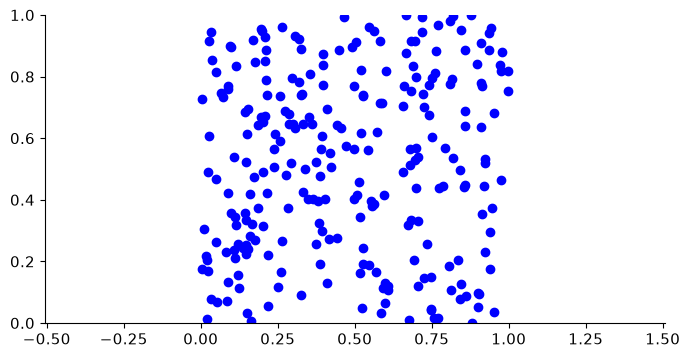

In [21]:
import ipywidgets as widgets


@widgets.interact(t=(0, niter // save_per - 1))
def display_frame(t=0):
    s = t / (niter // save_per - 1)
    plt.scatter(Zsvg[:, 0, t], Zsvg[:, 1, t], color=[s, 0, 1 - s])
    plt.axis("equal")
    plt.axis([0, 1, 0, 1])

## References and further reading

- Arthur Gretton et al.. [A Kernel Two-Sample Test](https://www.jmlr.org/papers/v13/gretton12a.html). 2012, JMLR 13, 723–773. Mean embeddings and maximum mean discrepancy.

- Benjamin Charlier, Jean Feydy, Joan Alexis Glaunès, François-David Collin, and Ghislain Durif. [Kernel Operations on the GPU, with Autodiff, without Memory Overflows](https://www.jmlr.org/papers/v22/20-275.html). 2021, JMLR 22(74), 1–6. Scalable reductions of large pairwise interaction matrices.

- Gabriel Peyré and Marco Cuturi. [Computational Optimal Transport](https://arxiv.org/abs/1803.00567). 2019, Foundations and Trends in Machine Learning 11(5–6), 355–607. Transport plans, duality, entropic regularization, and applications.

- Léon Bottou, Frank E. Curtis, and Jorge Nocedal. [Optimization Methods for Large-Scale Machine Learning](https://arxiv.org/abs/1606.04838). 2018, SIAM Review 60(2), 223–311. Stochastic gradients, variance reduction, and practical convergence.

- Ian Goodfellow, Yoshua Bengio, and Aaron Courville. [Deep Learning](https://www.deeplearningbook.org/). 2016, MIT Press. Neural networks, automatic differentiation, and optimization.
